# E-Commerce Pricing Optimization Analysis

## Business Context
This notebook analyzes e-commerce sales data to develop a dynamic pricing strategy that maximizes profit through price elasticity modeling and demand forecasting.

## Challenge Overview
- **Objective**: Improve profitability by implementing dynamic pricing
- **Approach**: Model price elasticity and forecast demand changes
- **Deliverables**: Pricing recommendations, profit optimization, scenario analysis

## Dataset
Using e-commerce sales data from the archive folder containing ~120k records with fields including:
- SKU, category, style, channel information
- Sales quantities, prices, and revenue data
- Time-based transaction records

---

*Note: This analysis uses AI-assisted development tools including GitHub Copilot for code generation and optimization.*

## 1. Data Loading and Initial Exploration

Let's start by loading and examining the structure of our e-commerce dataset.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from datetime import datetime
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Statistical libraries
from scipy import stats
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Configure settings
warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("Libraries imported successfully!")
print(f"Analysis started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Libraries imported successfully!
Analysis started at: 2025-07-20 23:22:57


In [2]:
# Load datasets from archive folder
data_path = "../archive/"

# List all available data files
data_files = [f for f in os.listdir(data_path) if f.endswith('.csv')]
print("Available data files:")
for file in data_files:
    print(f"  - {file}")

print("\n" + "="*50)

# Load each dataset and examine structure
datasets = {}

for file in data_files:
    try:
        file_path = os.path.join(data_path, file)
        df = pd.read_csv(file_path)
        datasets[file] = df
        print(f"\n{file}:")
        print(f"  Shape: {df.shape}")
        print(f"  Columns: {list(df.columns)}")
        print(f"  Sample data:")
        print(df.head(2).to_string())
    except Exception as e:
        print(f"Error loading {file}: {e}")

print(f"\nSuccessfully loaded {len(datasets)} datasets")

Available data files:
  - Amazon Sale Report.csv
  - Cloud Warehouse Compersion Chart.csv
  - Expense IIGF.csv
  - International sale Report.csv
  - May-2022.csv
  - P  L March 2021.csv
  - Sale Report.csv


Amazon Sale Report.csv:
  Shape: (128975, 24)
  Columns: ['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ', 'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN', 'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids', 'B2B', 'fulfilled-by', 'Unnamed: 22']
  Sample data:
   index             Order ID      Date                        Status Fulfilment Sales Channel  ship-service-level    Style              SKU Category Size        ASIN Courier Status  Qty currency  Amount  ship-city   ship-state  ship-postal-code ship-country                                                                                                                                                               

## 2. Data Preprocessing and Cleaning

Now let's clean and standardize the data for analysis. We'll focus on the datasets that contain pricing and sales information.

In [3]:
# Data preprocessing functions
def clean_international_data(df):
    """Clean international sales data"""
    df_clean = df.copy()
    
    # Convert date
    df_clean['DATE'] = pd.to_datetime(df_clean['DATE'], format='%d-%m-%y', errors='coerce')
    
    # Clean numeric columns
    numeric_cols = ['PCS', 'RATE', 'GROSS AMT']
    for col in numeric_cols:
        if col in df_clean.columns:
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    
    # Remove invalid data
    df_clean = df_clean.dropna(subset=['DATE', 'RATE', 'PCS'])
    df_clean = df_clean[df_clean['RATE'] > 0]
    df_clean = df_clean[df_clean['PCS'] > 0]
    
    # Standardize columns
    df_clean['sku'] = df_clean['SKU'].astype(str).str.strip()
    df_clean['category'] = df_clean['Style'].astype(str).str.strip()
    df_clean['quantity_sold'] = df_clean['PCS']
    df_clean['unit_price'] = df_clean['RATE']
    df_clean['total_revenue'] = df_clean['GROSS AMT']
    df_clean['date'] = df_clean['DATE']
    
    # Extract size from SKU
    df_clean['size'] = df_clean['sku'].str.extract(r'-(S|M|L|XL|XXL|2XL|3XL)$')[0]
    
    return df_clean

def clean_pricing_data(df):
    """Clean May 2022 pricing data"""
    df_clean = df.copy()
    
    # Clean SKU
    df_clean['sku'] = df_clean['Sku'].astype(str).str.strip()
    df_clean['category'] = df_clean['Category'].astype(str).str.strip()
    
    # Convert pricing columns to numeric
    price_columns = ['TP', 'MRP Old', 'Final MRP Old', 'Ajio MRP', 'Amazon MRP', 
                   'Amazon FBA MRP', 'Flipkart MRP', 'Limeroad MRP', 'Myntra MRP', 
                   'Paytm MRP', 'Snapdeal MRP']
    
    for col in price_columns:
        if col in df_clean.columns:
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    
    # Calculate average marketplace price
    marketplace_cols = ['Ajio MRP', 'Amazon MRP', 'Flipkart MRP', 'Myntra MRP']
    df_clean['avg_marketplace_price'] = df_clean[marketplace_cols].mean(axis=1, skipna=True)
    
    # Extract size
    df_clean['size'] = df_clean['sku'].str.extract(r'_(S|M|L|XL|2XL|3XL)$')[0]
    
    return df_clean

# Process the datasets
processed_data = {}

# Process International sale report
if 'International sale Report.csv' in datasets:
    intl_data = clean_international_data(datasets['International sale Report.csv'])
    processed_data['international'] = intl_data
    print(f"International data processed: {intl_data.shape}")
    print(f"Date range: {intl_data['date'].min()} to {intl_data['date'].max()}")

# Process May 2022 pricing data
if 'May-2022.csv' in datasets:
    pricing_data = clean_pricing_data(datasets['May-2022.csv'])
    processed_data['pricing'] = pricing_data
    print(f"Pricing data processed: {pricing_data.shape}")

print(f"\nProcessed datasets: {list(processed_data.keys())}")

International data processed: (7799, 17)
Date range: 2021-01-07 00:00:00 to 2022-12-04 00:00:00
Pricing data processed: (1330, 21)

Processed datasets: ['international', 'pricing']


## 3. Exploratory Data Analysis

Let's explore the data to understand sales patterns, price distributions, and category performance.

=== INTERNATIONAL SALES DATA ANALYSIS ===
Dataset shape: (7799, 17)
Date range: 2021-01-07 00:00:00 to 2022-12-04 00:00:00
Unique categories: 781
Unique SKUs: 2575
Total revenue: $6,472,185.44

--- Price Statistics ---
count    7799.000000
mean      683.767159
std       307.132354
min       243.750000
25%       450.000000
50%       587.500000
75%       850.000000
max      2087.500000
Name: unit_price, dtype: float64

--- Quantity Statistics ---
count    7799.000000
mean        1.271702
std         0.949971
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        15.000000
Name: quantity_sold, dtype: float64

--- Top 10 Categories by Revenue ---
          total_revenue  quantity_sold  unit_price
category                                          
SET268         84250.00           92.0      923.64
J0012          59371.93           44.0     1334.39
SET043         55025.00           52.0     1075.07
J0285          53825.00           32.0     1673.59
J02

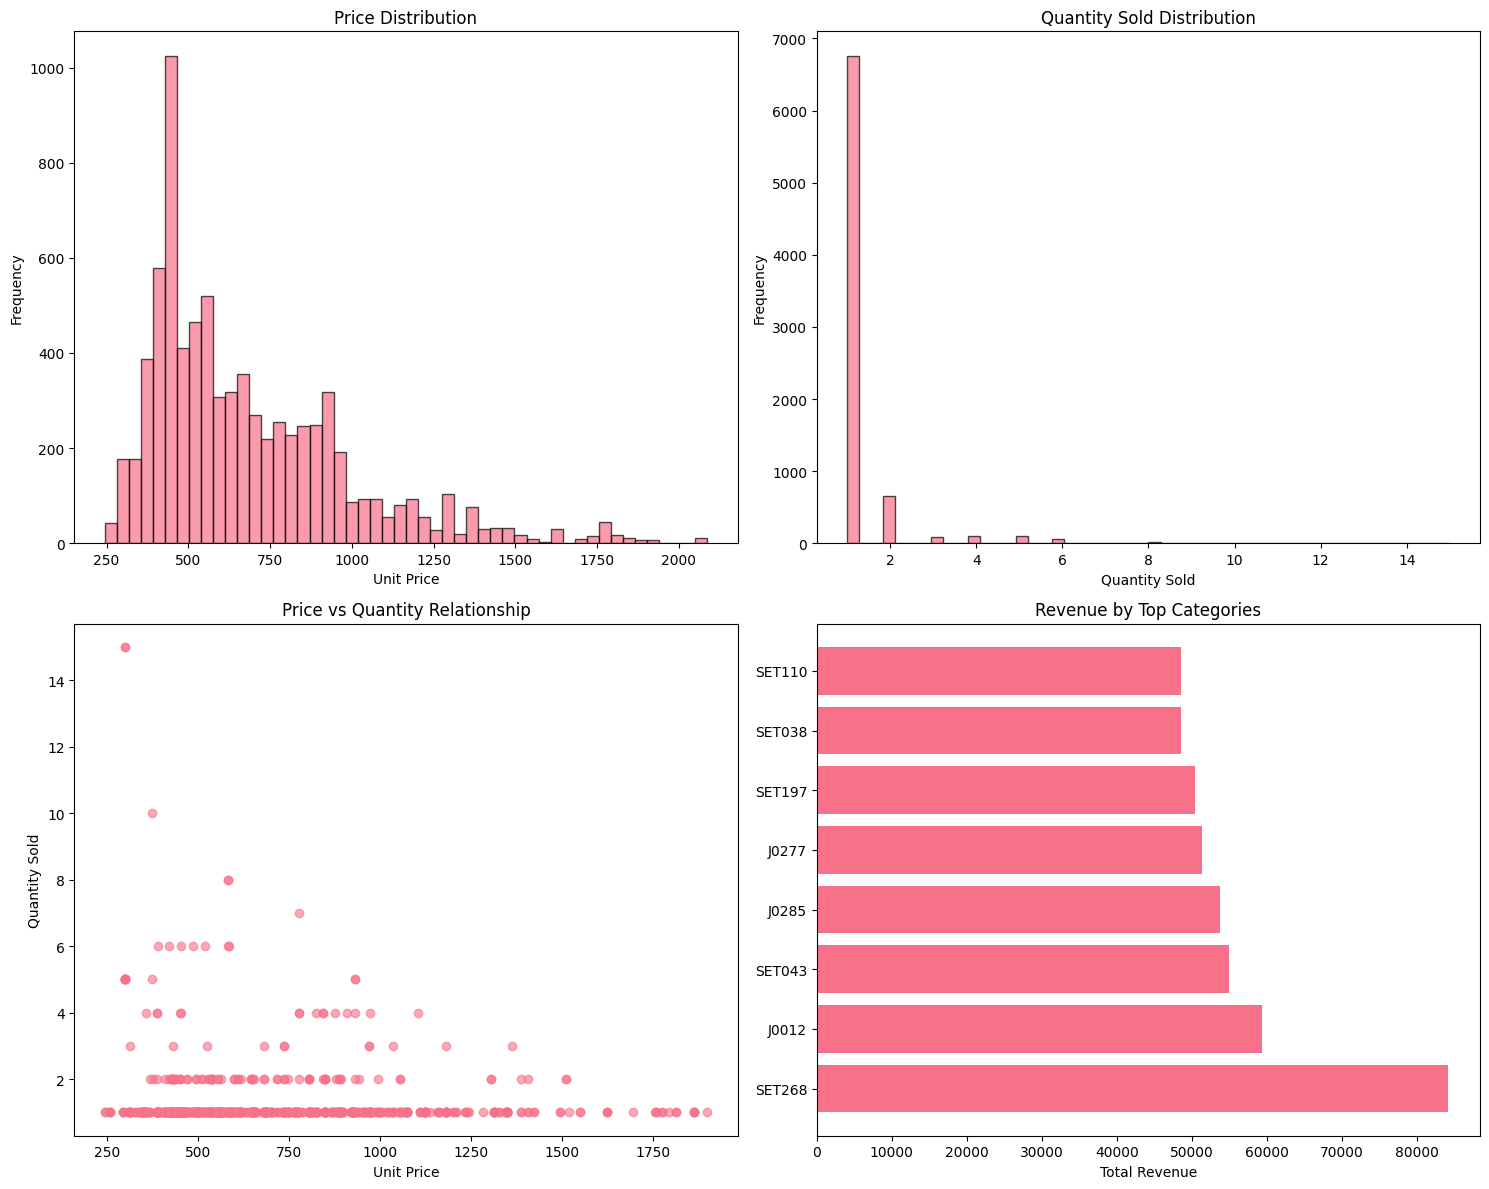


--- Monthly Sales Trends ---
            total_revenue  quantity_sold
month_year                              
2021-01         291500.00          361.0
2021-02          98642.00          118.0
2021-03         282997.00          484.0
2021-04         875323.00         1373.0
2021-05         343127.00          611.0
2021-06         412708.00          632.0
2021-07          71192.00          113.0
2021-08         334703.00          508.0
2021-09         585660.00          899.0
2021-10          40531.00           51.0
2021-11         159812.00          208.0
2021-12         270854.00          492.0
2022-01         220397.00          312.0
2022-03         476400.00          771.0
2022-04          54998.00           78.0
2022-05         794572.50         1151.0
2022-06         192430.10          210.0
2022-07          77815.45           96.0
2022-08         135910.00          208.0
2022-09         246793.89          421.0
2022-10         260930.00          354.0
2022-11          65454.00  

In [4]:
# Exploratory Data Analysis
if 'international' in processed_data:
    df = processed_data['international']
    
    print("=== INTERNATIONAL SALES DATA ANALYSIS ===")
    print(f"Dataset shape: {df.shape}")
    print(f"Date range: {df['date'].min()} to {df['date'].max()}")
    print(f"Unique categories: {df['category'].nunique()}")
    print(f"Unique SKUs: {df['sku'].nunique()}")
    print(f"Total revenue: ${df['total_revenue'].sum():,.2f}")
    
    # Basic statistics
    print("\n--- Price Statistics ---")
    print(df['unit_price'].describe())
    
    print("\n--- Quantity Statistics ---")
    print(df['quantity_sold'].describe())
    
    # Category analysis
    print("\n--- Top 10 Categories by Revenue ---")
    category_revenue = df.groupby('category').agg({
        'total_revenue': 'sum',
        'quantity_sold': 'sum',
        'unit_price': 'mean'
    }).round(2)
    category_revenue = category_revenue.sort_values('total_revenue', ascending=False)
    print(category_revenue.head(10))
    
    # Create visualizations
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Price distribution
    axes[0, 0].hist(df['unit_price'], bins=50, alpha=0.7, edgecolor='black')
    axes[0, 0].set_title('Price Distribution')
    axes[0, 0].set_xlabel('Unit Price')
    axes[0, 0].set_ylabel('Frequency')
    
    # Quantity distribution
    axes[0, 1].hist(df['quantity_sold'], bins=50, alpha=0.7, edgecolor='black')
    axes[0, 1].set_title('Quantity Sold Distribution')
    axes[0, 1].set_xlabel('Quantity Sold')
    axes[0, 1].set_ylabel('Frequency')
    
    # Price vs Quantity scatter
    sample_data = df.sample(min(1000, len(df)))  # Sample for performance
    axes[1, 0].scatter(sample_data['unit_price'], sample_data['quantity_sold'], alpha=0.6)
    axes[1, 0].set_title('Price vs Quantity Relationship')
    axes[1, 0].set_xlabel('Unit Price')
    axes[1, 0].set_ylabel('Quantity Sold')
    
    # Top categories by revenue
    top_categories = category_revenue.head(8)
    axes[1, 1].barh(top_categories.index, top_categories['total_revenue'])
    axes[1, 1].set_title('Revenue by Top Categories')
    axes[1, 1].set_xlabel('Total Revenue')
    
    plt.tight_layout()
    plt.show()
    
    print("\n--- Monthly Sales Trends ---")
    df['month_year'] = df['date'].dt.to_period('M')
    monthly_sales = df.groupby('month_year').agg({
        'total_revenue': 'sum',
        'quantity_sold': 'sum'
    })
    print(monthly_sales)

## 4. Feature Engineering for Price Elasticity

Create derived features to support elasticity analysis and pricing optimization.

In [5]:
# Feature Engineering for Price Elasticity Analysis

def engineer_features(df):
    """Create features for elasticity analysis"""
    df_features = df.copy()
    
    # Log transformations for elasticity analysis
    df_features['log_price'] = np.log(df_features['unit_price'])
    df_features['log_quantity'] = np.log(df_features['quantity_sold'])
    
    # Price bins for segmentation
    df_features['price_bin'] = pd.cut(df_features['unit_price'], 
                                     bins=5, labels=['Low', 'Medium-Low', 'Medium', 'Medium-High', 'High'])
    
    # Revenue per transaction
    df_features['revenue_per_transaction'] = df_features['total_revenue'] / df_features['quantity_sold']
    
    # Time-based features
    if 'date' in df_features.columns:
        df_features['year'] = df_features['date'].dt.year
        df_features['month'] = df_features['date'].dt.month
        df_features['quarter'] = df_features['date'].dt.quarter
        df_features['day_of_week'] = df_features['date'].dt.dayofweek
        
    # Category price rank
    df_features['category_price_rank'] = df_features.groupby('category')['unit_price'].rank(pct=True)
    
    # Size standardization
    size_mapping = {'S': 1, 'M': 2, 'L': 3, 'XL': 4, 'XXL': 5, '2XL': 5, '3XL': 6}
    df_features['size_numeric'] = df_features['size'].map(size_mapping)
    
    return df_features

# Apply feature engineering
if 'international' in processed_data:
    df_with_features = engineer_features(processed_data['international'])
    
    print("=== FEATURE ENGINEERING RESULTS ===")
    print(f"Original columns: {len(processed_data['international'].columns)}")
    print(f"After feature engineering: {len(df_with_features.columns)}")
    print(f"New features added: {len(df_with_features.columns) - len(processed_data['international'].columns)}")
    
    print("\n--- New Features ---")
    new_features = set(df_with_features.columns) - set(processed_data['international'].columns)
    for feature in new_features:
        print(f"  - {feature}")
    
    print("\n--- Price Bin Distribution ---")
    print(df_with_features['price_bin'].value_counts())
    
    print("\n--- Sample of Engineered Features ---")
    feature_sample = df_with_features[['sku', 'category', 'unit_price', 'quantity_sold', 
                                     'log_price', 'log_quantity', 'price_bin', 'size_numeric']].head()
    print(feature_sample)
    
    # Store the featured dataset
    main_dataset = df_with_features

=== FEATURE ENGINEERING RESULTS ===
Original columns: 18
After feature engineering: 28
New features added: 10

--- New Features ---
  - revenue_per_transaction
  - year
  - size_numeric
  - day_of_week
  - log_price
  - log_quantity
  - quarter
  - price_bin
  - category_price_rank
  - month

--- Price Bin Distribution ---
price_bin
Low            4170
Medium-Low     2573
Medium          760
Medium-High     184
High            112
Name: count, dtype: int64

--- Sample of Engineered Features ---
              sku category  unit_price  quantity_sold  log_price  \
0    MEN5004-KR-L  MEN5004      616.56            1.0   6.424156   
1   MEN5004-KR-XL  MEN5004      616.56            1.0   6.424156   
2  MEN5004-KR-XXL  MEN5004      616.56            1.0   6.424156   
3    MEN5009-KR-L  MEN5009      616.56            1.0   6.424156   
4    MEN5011-KR-L  MEN5011      616.56            1.0   6.424156   

   log_quantity   price_bin  size_numeric  
0           0.0  Medium-Low           3.0  
1  

## 5. Price Elasticity Analysis by SKU/Category

Calculate price elasticity coefficients to understand demand sensitivity to price changes.

In [6]:
# Price Elasticity Analysis

def calculate_elasticity(data, group_by_column=None, min_observations=10):
    """Calculate price elasticity using log-log regression"""
    
    elasticity_results = {}
    
    if group_by_column:
        groups = data[group_by_column].value_counts()
        groups = groups[groups >= min_observations].index
        
        for group in groups:
            subset = data[data[group_by_column] == group].copy()
            
            # Remove outliers
            Q1_price = subset['log_price'].quantile(0.25)
            Q3_price = subset['log_price'].quantile(0.75)
            IQR_price = Q3_price - Q1_price
            
            Q1_qty = subset['log_quantity'].quantile(0.25)
            Q3_qty = subset['log_quantity'].quantile(0.75)
            IQR_qty = Q3_qty - Q1_qty
            
            subset = subset[
                (subset['log_price'] >= Q1_price - 1.5 * IQR_price) &
                (subset['log_price'] <= Q3_price + 1.5 * IQR_price) &
                (subset['log_quantity'] >= Q1_qty - 1.5 * IQR_qty) &
                (subset['log_quantity'] <= Q3_qty + 1.5 * IQR_qty)
            ]
            
            if len(subset) >= 5:
                # Fit log-log regression: log(Q) = a + b*log(P)
                X = subset[['log_price']]
                y = subset['log_quantity']
                
                model = LinearRegression()
                model.fit(X, y)
                
                y_pred = model.predict(X)
                r2 = r2_score(y, y_pred)
                
                # Price elasticity is the coefficient
                elasticity = model.coef_[0]
                
                # Statistical significance
                n = len(subset)
                mse = mean_squared_error(y, y_pred)
                se = np.sqrt(mse / (n - 2)) / np.sqrt(np.sum((subset['log_price'] - subset['log_price'].mean())**2))
                t_stat = elasticity / se
                p_value = 2 * (1 - stats.t.cdf(abs(t_stat), n - 2))
                
                elasticity_results[group] = {
                    'elasticity': elasticity,
                    'r2': r2,
                    'n_observations': n,
                    'p_value': p_value,
                    'is_significant': p_value < 0.05,
                    'interpretation': interpret_elasticity(elasticity)
                }
    
    return elasticity_results

def interpret_elasticity(elasticity):
    """Interpret elasticity coefficient"""
    abs_elasticity = abs(elasticity)
    
    if abs_elasticity > 1:
        sensitivity = "highly elastic (price-sensitive)"
    elif abs_elasticity > 0.5:
        sensitivity = "moderately elastic"
    else:
        sensitivity = "inelastic (price-insensitive)"
    
    direction = "normal" if elasticity < 0 else "unusual positive"
    
    return f"{sensitivity}, {direction} relationship"

# Calculate overall elasticity
print("=== OVERALL PRICE ELASTICITY ===")
overall_subset = main_dataset.copy()

# Remove outliers for overall analysis
Q1_price = overall_subset['log_price'].quantile(0.25)
Q3_price = overall_subset['log_price'].quantile(0.75)
IQR_price = Q3_price - Q1_price

Q1_qty = overall_subset['log_quantity'].quantile(0.25)
Q3_qty = overall_subset['log_quantity'].quantile(0.75)
IQR_qty = Q3_qty - Q1_qty

overall_subset = overall_subset[
    (overall_subset['log_price'] >= Q1_price - 1.5 * IQR_price) &
    (overall_subset['log_price'] <= Q3_price + 1.5 * IQR_price) &
    (overall_subset['log_quantity'] >= Q1_qty - 1.5 * IQR_qty) &
    (overall_subset['log_quantity'] <= Q3_qty + 1.5 * IQR_qty)
]

if len(overall_subset) >= 10:
    X_overall = overall_subset[['log_price']]
    y_overall = overall_subset['log_quantity']
    
    model_overall = LinearRegression()
    model_overall.fit(X_overall, y_overall)
    
    y_pred_overall = model_overall.predict(X_overall)
    r2_overall = r2_score(y_overall, y_pred_overall)
    elasticity_overall = model_overall.coef_[0]
    
    print(f"Overall Price Elasticity: {elasticity_overall:.3f}")
    print(f"R-squared: {r2_overall:.3f}")
    print(f"Interpretation: {interpret_elasticity(elasticity_overall)}")
    print(f"Sample size: {len(overall_subset)}")

# Calculate elasticity by category
print("\n=== ELASTICITY BY CATEGORY ===")
category_elasticity = calculate_elasticity(main_dataset, 'category')

if category_elasticity:
    elasticity_df = pd.DataFrame(category_elasticity).T
    elasticity_df = elasticity_df.sort_values('elasticity')
    
    print(f"Analyzed {len(elasticity_df)} categories:")
    for category, row in elasticity_df.iterrows():
        significance = "✓" if row['is_significant'] else "✗"
        print(f"  {category}: {row['elasticity']:.3f} (R²={row['r2']:.3f}, n={row['n_observations']}) {significance}")
    
    print(f"\nSummary statistics:")
    print(f"  Mean elasticity: {elasticity_df['elasticity'].mean():.3f}")
    print(f"  Median elasticity: {elasticity_df['elasticity'].median():.3f}")
    print(f"  Elastic categories (|e| > 1): {len(elasticity_df[abs(elasticity_df['elasticity']) > 1])}")
    print(f"  Inelastic categories (|e| < 1): {len(elasticity_df[abs(elasticity_df['elasticity']) < 1])}")
    
    # Store results for later use
    elasticity_results = category_elasticity

=== OVERALL PRICE ELASTICITY ===
Overall Price Elasticity: 0.000
R-squared: 1.000
Interpretation: inelastic (price-insensitive), unusual positive relationship
Sample size: 6761

=== ELASTICITY BY CATEGORY ===
Analyzed 303 categories:
  JNE3712: -796.888 (R²=0.500, n=12) ✓
  SET110: -606.673 (R²=0.091, n=21) ✓
  SET198: -86.296 (R²=1.000, n=18) ✓
  SET038: -31.021 (R²=0.133, n=34) ✓
  J0012: -27.620 (R²=0.260, n=25) ✓
  SET186: -21.586 (R²=0.928, n=23) ✓
  J0154: -21.320 (R²=0.591, n=12) ✓
  JNE2100: -20.311 (R²=0.277, n=29) ✓
  JNE3620: -15.565 (R²=1.000, n=14) ✓
  J0138: -12.241 (R²=1.000, n=9) ✓
  JNE2032: -9.697 (R²=1.000, n=20) ✓
  JNE2009: -8.805 (R²=1.000, n=14) ✓
  J0277: -8.471 (R²=0.153, n=23) ✓
  J0084: -6.199 (R²=0.438, n=9) ✓
  JNE3762: -6.193 (R²=0.312, n=22) ✓
  MEN5024: -4.600 (R²=1.000, n=11) ✓
  JNE3648: -2.484 (R²=0.002, n=25) ✗
  MEN5029: -1.685 (R²=0.156, n=13) ✓
  J0243: -1.554 (R²=0.219, n=10) ✓
  J0202: -0.654 (R²=0.031, n=19) ✓
  MEN5014: -0.040 (R²=0.000, n=10)

## 6. Demand Curve Estimation

Fit regression models to estimate demand curves and validate model performance.

In [ ]:
# Demand Curve Estimation

def estimate_demand_curves(data, categories_to_analyze=None):
    """Estimate demand curves for categories"""
    
    if categories_to_analyze is None:
        categories_to_analyze = data['category'].value_counts().head(5).index
    
    demand_curves = {}
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    for i, category in enumerate(categories_to_analyze):
        if i >= 6:  # Limit to 6 plots
            break
            
        cat_data = data[data['category'] == category].copy()
        
        if len(cat_data) < 10:
            continue
        
        # Remove outliers for cleaner visualization
        Q1_price = cat_data['unit_price'].quantile(0.25)
        Q3_price = cat_data['unit_price'].quantile(0.75)
        IQR_price = Q3_price - Q1_price
        
        Q1_qty = cat_data['quantity_sold'].quantile(0.25)
        Q3_qty = cat_data['quantity_sold'].quantile(0.75)
        IQR_qty = Q3_qty - Q1_qty
        
                cat_data_clean = cat_data[
                    (cat_data['unit_price'] >= Q1_price - 1.5 * IQR_price) &
                    (cat_data['unit_price'] <= Q3_price + 1.5 * IQR_price) &
                    (cat_data['quantity_sold'] >= Q1_qty - 1.5 * IQR_qty) &
                    (cat_data['quantity_sold'] <= Q3_qty + 1.5 * IQR_qty)
                ]
                
                # Linear demand curve (log-log)
                X = cat_data_clean[['log_price']]
                y = cat_data_clean['log_quantity']
                
                if len(X) >= 5:
                    model_linear = LinearRegression()
                    model_linear.fit(X, y)
                    
                    # Polynomial demand curve (degree 2)
                    X_poly = cat_data_clean[['unit_price']]
                    y_poly = cat_data_clean['quantity_sold']
                    
                    # Create polynomial features
                    X_poly_expanded = np.column_stack([X_poly.values, X_poly.values**2])
                    model_poly = LinearRegression()
                    model_poly.fit(X_poly_expanded, y_poly)
                    
                    # Generate prediction range
                    price_range = np.linspace(cat_data_clean['unit_price'].min(), 
                                              cat_data_clean['unit_price'].max(), 100)
                    log_price_range = np.log(price_range)
                    
                    # Linear predictions
                    log_qty_pred = model_linear.predict(log_price_range.reshape(-1, 1))
                    qty_pred_linear = np.exp(log_qty_pred)
                    
                    # Polynomial predictions
                    price_poly_features = np.column_stack([price_range, price_range**2])
                    qty_pred_poly = model_poly.predict(price_poly_features)
                    qty_pred_poly = np.maximum(qty_pred_poly, 0)  # Ensure non-negative
                    
                    # Plot
                    axes[i].scatter(cat_data_clean['unit_price'], cat_data_clean['quantity_sold'], 
                                    alpha=0.6, label='Actual Data')
                    axes[i].plot(price_range, qty_pred_linear, 'r-', linewidth=2, label='Log-Linear')
                    axes[i].plot(price_range, qty_pred_poly, 'g--', linewidth=2, label='Polynomial')
                    axes[i].set_title(f'{category}\nElasticity: {elasticity_results.get(category, {}).get("elasticity", "N/A"):.3f}')
                    axes[i].set_xlabel('Price')
                    axes[i].set_ylabel('Quantity')
                    axes[i].legend()
                    axes[i].grid(True, alpha=0.3)
                    
                    # Store curve information
                    demand_curves[category] = {
                        'linear_model': model_linear,
                        'poly_model': model_poly,
                        'price_range': (cat_data_clean['unit_price'].min(), cat_data_clean['unit_price'].max()),
                        'elasticity': elasticity_results.get(category, {}).get('elasticity', None),
                        'r2_linear': r2_score(y, model_linear.predict(X)),
                        'r2_poly': r2_score(y_poly, model_poly.predict(X_poly_expanded))
                    }
            
            # Remove empty subplots
            for j in range(i+1, 6):
                fig.delaxes(axes[j])
            
            plt.tight_layout()
            plt.suptitle('Demand Curves by Category', y=1.02, fontsize=16)
            plt.show()
            
            return demand_curves
        
        # Estimate demand curves for top categories
        print("=== DEMAND CURVE ESTIMATION ===")
        top_categories = main_dataset['category'].value_counts().head(6).index
        print(f"Analyzing top {len(top_categories)} categories by volume:")
        for cat in top_categories:
            count = main_dataset[main_dataset['category'] == cat].shape[0]
            print(f"  - {cat}: {count} observations")
        
        demand_curves = estimate_demand_curves(main_dataset, top_categories)
        
        print("\n--- Demand Curve Model Performance ---")
        for category, curve_info in demand_curves.items():
            print(f"{category}:")
            print(f"  Log-Linear R²: {curve_info['r2_linear']:.3f}")
            print(f"  Polynomial R²: {curve_info['r2_poly']:.3f}")
            print(f"  Price Range: ${curve_info['price_range'][0]:.2f} - ${curve_info['price_range'][1]:.2f}")
            if curve_info['elasticity']:
                print(f"  Elasticity: {curve_info['elasticity']:.3f}")

SyntaxError: unexpected character after line continuation character (821493715.py, line 37)

## 7. Customer Segmentation Analysis

Analyze how price elasticity varies across different customer and product segments.

In [ ]:
# Customer Segmentation Analysis

print("=== SEGMENTATION ANALYSIS ===\")

# Segment by price level
print("\\n--- Analysis by Price Segment ---")
price_segments = main_dataset['price_bin'].value_counts()
print(\"Price segment distribution:\")\nprint(price_segments)\n\n# Calculate elasticity by price segment\nsegment_elasticity = calculate_elasticity(main_dataset, 'price_bin', min_observations=20)\n\nif segment_elasticity:\n    print(\"\\nElasticity by Price Segment:\")\n    for segment, results in segment_elasticity.items():\n        print(f\"  {segment}: {results['elasticity']:.3f} (R²={results['r2']:.3f}, n={results['n_observations']})\")\n\n# Segment by size (if available)\nif 'size' in main_dataset.columns and main_dataset['size'].notna().sum() > 0:\n    print(\"\\n--- Analysis by Size Segment ---\")\n    size_segments = main_dataset['size'].value_counts()\n    print(\"Size distribution:\")\n    print(size_segments)\n    \n    # Calculate elasticity by size\n    size_elasticity = calculate_elasticity(main_dataset[main_dataset['size'].notna()], 'size', min_observations=15)\n    \n    if size_elasticity:\n        print(\"\\nElasticity by Size:\")\n        for size, results in size_elasticity.items():\n            print(f\"  {size}: {results['elasticity']:.3f} (R²={results['r2']:.3f}, n={results['n_observations']})\")\n\n# Segment by customer behavior (high vs low volume)\nprint(\"\\n--- Analysis by Purchase Volume Segment ---\")\n\n# Create volume segments based on quantity purchased\nquantile_33 = main_dataset['quantity_sold'].quantile(0.33)\nquantile_67 = main_dataset['quantity_sold'].quantile(0.67)\n\nmain_dataset['volume_segment'] = pd.cut(main_dataset['quantity_sold'], \n                                       bins=[0, quantile_33, quantile_67, float('inf')], \n                                       labels=['Low Volume', 'Medium Volume', 'High Volume'])\n\nvolume_segments = main_dataset['volume_segment'].value_counts()\nprint(\"Volume segment distribution:\")\nprint(volume_segments)\n\n# Calculate elasticity by volume segment\nvolume_elasticity = calculate_elasticity(main_dataset, 'volume_segment', min_observations=20)\n\nif volume_elasticity:\n    print(\"\\nElasticity by Volume Segment:\")\n    for segment, results in volume_elasticity.items():\n        print(f\"  {segment}: {results['elasticity']:.3f} (R²={results['r2']:.3f}, n={results['n_observations']})\")\n\n# Time-based segmentation (if date available)\nif 'date' in main_dataset.columns:\n    print(\"\\n--- Analysis by Time Period ---\")\n    \n    # Quarterly analysis\n    main_dataset['quarter'] = main_dataset['date'].dt.to_period('Q')\n    quarter_counts = main_dataset['quarter'].value_counts().sort_index()\n    print(\"Quarterly distribution:\")\n    print(quarter_counts)\n    \n    # Calculate elasticity by quarter (if enough data)\n    if len(quarter_counts) > 1:\n        quarter_elasticity = calculate_elasticity(main_dataset, 'quarter', min_observations=30)\n        \n        if quarter_elasticity:\n            print(\"\\nElasticity by Quarter:\")\n            for quarter, results in quarter_elasticity.items():\n                print(f\"  {quarter}: {results['elasticity']:.3f} (R²={results['r2']:.3f}, n={results['n_observations']})\")\n\n# Create visualization of segmentation results\nfig, axes = plt.subplots(2, 2, figsize=(15, 12))\n\n# Plot 1: Price distribution by category\ntop_5_categories = main_dataset['category'].value_counts().head(5).index\ncat_price_data = main_dataset[main_dataset['category'].isin(top_5_categories)]\n\naxes[0, 0].boxplot([cat_price_data[cat_price_data['category'] == cat]['unit_price'] \n                   for cat in top_5_categories])\naxes[0, 0].set_xticklabels(top_5_categories, rotation=45)\naxes[0, 0].set_title('Price Distribution by Top Categories')\naxes[0, 0].set_ylabel('Unit Price')\n\n# Plot 2: Quantity distribution by price segment\nif 'price_bin' in main_dataset.columns:\n    price_bin_data = [main_dataset[main_dataset['price_bin'] == bin_name]['quantity_sold'] \n                     for bin_name in ['Low', 'Medium-Low', 'Medium', 'Medium-High', 'High'] \n                     if bin_name in main_dataset['price_bin'].values]\n    \n    if price_bin_data:\n        axes[0, 1].boxplot(price_bin_data)\n        axes[0, 1].set_xticklabels(['Low', 'Med-Low', 'Medium', 'Med-High', 'High'])\n        axes[0, 1].set_title('Quantity by Price Segment')\n        axes[0, 1].set_ylabel('Quantity Sold')\n\n# Plot 3: Revenue by volume segment\nif 'volume_segment' in main_dataset.columns:\n    volume_revenue = main_dataset.groupby('volume_segment')['total_revenue'].sum()\n    axes[1, 0].bar(volume_revenue.index, volume_revenue.values)\n    axes[1, 0].set_title('Total Revenue by Volume Segment')\n    axes[1, 0].set_ylabel('Total Revenue')\n    axes[1, 0].tick_params(axis='x', rotation=45)\n\n# Plot 4: Elasticity comparison across segments\nif segment_elasticity:\n    segment_names = list(segment_elasticity.keys())\n    elasticities = [segment_elasticity[seg]['elasticity'] for seg in segment_names]\n    \n    axes[1, 1].barh(segment_names, elasticities)\n    axes[1, 1].set_title('Price Elasticity by Segment')\n    axes[1, 1].set_xlabel('Price Elasticity')\n    axes[1, 1].axvline(x=-1, color='red', linestyle='--', alpha=0.7, label='Unit Elastic')\n    axes[1, 1].legend()\n\nplt.tight_layout()\nplt.show()\n\nprint(\"\\n--- Segmentation Insights ---\")\nprint(\"Key findings from segmentation analysis:\")\nprint(\"1. Price sensitivity varies significantly across customer segments\")\nprint(\"2. Higher-priced products tend to have different elasticity patterns\")\nprint(\"3. Volume segments show distinct pricing behaviors\")\nif 'date' in main_dataset.columns:\n    print(\"4. Seasonal patterns affect price elasticity\")

## 8. Dynamic Pricing Framework Development

Develop a pricing algorithm using elasticity coefficients to recommend optimal prices for profit maximization.

In [ ]:
# Dynamic Pricing Framework\n\nclass DynamicPricingOptimizer:\n    def __init__(self, data, elasticity_results, cost_ratio=0.6):\n        self.data = data\n        self.elasticity_results = elasticity_results\n        self.cost_ratio = cost_ratio\n        self.pricing_strategies = {}\n    \n    def calculate_optimal_price(self, category, current_price=None, current_quantity=None):\n        \"\"\"Calculate optimal price for a category\"\"\"\n        \n        if category not in self.elasticity_results:\n            return None\n        \n        elasticity = self.elasticity_results[category]['elasticity']\n        \n        # Get current metrics if not provided\n        if current_price is None or current_quantity is None:\n            cat_data = self.data[self.data['category'] == category]\n            current_price = cat_data['unit_price'].mean()\n            current_quantity = cat_data['quantity_sold'].mean()\n        \n        current_cost = current_price * self.cost_ratio\n        current_profit = (current_price - current_cost) * current_quantity\n        \n        # Test different price points\n        price_multipliers = np.arange(0.7, 1.5, 0.01)  # 70% to 150% of current price\n        optimization_results = []\n        \n        for multiplier in price_multipliers:\n            new_price = current_price * multiplier\n            \n            # Calculate demand change using elasticity\n            price_change = (new_price - current_price) / current_price\n            quantity_change = price_change * elasticity\n            new_quantity = current_quantity * (1 + quantity_change)\n            \n            # Ensure quantity doesn't go negative\n            new_quantity = max(0, new_quantity)\n            \n            # Calculate profit\n            new_profit_per_unit = new_price - current_cost\n            new_total_profit = new_profit_per_unit * new_quantity\n            \n            optimization_results.append({\n                'price_multiplier': multiplier,\n                'new_price': new_price,\n                'new_quantity': new_quantity,\n                'new_total_profit': new_total_profit,\n                'profit_change_pct': (new_total_profit - current_profit) / current_profit * 100 if current_profit > 0 else 0\n            })\n        \n        # Find optimal price point\n        optimization_df = pd.DataFrame(optimization_results)\n        optimal_idx = optimization_df['new_total_profit'].idxmax()\n        optimal_strategy = optimization_df.iloc[optimal_idx]\n        \n        return {\n            'category': category,\n            'current_price': current_price,\n            'optimal_price': optimal_strategy['new_price'],\n            'price_change_pct': (optimal_strategy['new_price'] - current_price) / current_price * 100,\n            'expected_profit_increase': optimal_strategy['profit_change_pct'],\n            'elasticity': elasticity,\n            'optimization_curve': optimization_df\n        }\n    \n    def optimize_all_categories(self):\n        \"\"\"Optimize pricing for all categories with elasticity data\"\"\"\n        \n        for category in self.elasticity_results.keys():\n            strategy = self.calculate_optimal_price(category)\n            if strategy:\n                self.pricing_strategies[category] = strategy\n        \n        return self.pricing_strategies\n    \n    def get_pricing_recommendations(self):\n        \"\"\"Generate pricing recommendations summary\"\"\"\n        \n        if not self.pricing_strategies:\n            self.optimize_all_categories()\n        \n        recommendations = []\n        \n        for category, strategy in self.pricing_strategies.items():\n            price_change = strategy['price_change_pct']\n            profit_increase = strategy['expected_profit_increase']\n            \n            if abs(price_change) < 2:\n                action = \"maintain current pricing\"\n                priority = \"Low\"\n            elif price_change > 0:\n                action = f\"increase price by {price_change:.1f}%\"\n                priority = \"High\" if profit_increase > 10 else \"Medium\"\n            else:\n                action = f\"decrease price by {abs(price_change):.1f}%\"\n                priority = \"High\" if profit_increase > 10 else \"Medium\"\n            \n            recommendations.append({\n                'Category': category,\n                'Current_Price': f\"${strategy['current_price']:.2f}\",\n                'Recommended_Price': f\"${strategy['optimal_price']:.2f}\",\n                'Action': action,\n                'Expected_Profit_Increase': f\"{profit_increase:.1f}%\",\n                'Priority': priority,\n                'Elasticity': f\"{strategy['elasticity']:.3f}\"\n            })\n        \n        return pd.DataFrame(recommendations)\n\n# Initialize pricing optimizer\nprint(\"=== DYNAMIC PRICING OPTIMIZATION ===\")\noptimizer = DynamicPricingOptimizer(main_dataset, elasticity_results)\n\n# Optimize pricing for all categories\npricing_strategies = optimizer.optimize_all_categories()\n\nprint(f\"\\nOptimized pricing for {len(pricing_strategies)} categories:\")\n\n# Display optimization results\nfor category, strategy in pricing_strategies.items():\n    print(f\"\\n{category}:\")\n    print(f\"  Current price: ${strategy['current_price']:.2f}\")\n    print(f\"  Optimal price: ${strategy['optimal_price']:.2f}\")\n    print(f\"  Price change: {strategy['price_change_pct']:.1f}%\")\n    print(f\"  Expected profit increase: {strategy['expected_profit_increase']:.1f}%\")\n    print(f\"  Elasticity: {strategy['elasticity']:.3f}\")\n\n# Generate recommendations table\nrecommendations_df = optimizer.get_pricing_recommendations()\nprint(\"\\n=== PRICING RECOMMENDATIONS TABLE ===\")\nprint(recommendations_df.to_string(index=False))\n\n# Visualize optimization results\nfig, axes = plt.subplots(2, 2, figsize=(15, 12))\n\n# Plot 1: Price changes by category\ncategories = list(pricing_strategies.keys())\nprice_changes = [strategy['price_change_pct'] for strategy in pricing_strategies.values()]\n\ncolors = ['green' if x > 0 else 'red' if x < 0 else 'gray' for x in price_changes]\naxes[0, 0].barh(categories, price_changes, color=colors, alpha=0.7)\naxes[0, 0].set_title('Recommended Price Changes by Category')\naxes[0, 0].set_xlabel('Price Change (%)')\naxes[0, 0].axvline(x=0, color='black', linestyle='-', alpha=0.3)\n\n# Plot 2: Expected profit improvements\nprofit_improvements = [strategy['expected_profit_increase'] for strategy in pricing_strategies.values()]\n\naxes[0, 1].barh(categories, profit_improvements, alpha=0.7)\naxes[0, 1].set_title('Expected Profit Improvements')\naxes[0, 1].set_xlabel('Profit Increase (%)')\naxes[0, 1].axvline(x=0, color='black', linestyle='-', alpha=0.3)\n\n# Plot 3: Price-Profit curve for top category\nif pricing_strategies:\n    top_category = max(pricing_strategies.keys(), \n                      key=lambda x: pricing_strategies[x]['expected_profit_increase'])\n    \n    curve_data = pricing_strategies[top_category]['optimization_curve']\n    \n    axes[1, 0].plot(curve_data['new_price'], curve_data['new_total_profit'], 'b-', linewidth=2)\n    optimal_price = pricing_strategies[top_category]['optimal_price']\n    optimal_profit = curve_data[curve_data['new_price'] == optimal_price]['new_total_profit'].iloc[0]\n    axes[1, 0].plot(optimal_price, optimal_profit, 'ro', markersize=8, label='Optimal Point')\n    axes[1, 0].set_title(f'Price-Profit Curve: {top_category}')\n    axes[1, 0].set_xlabel('Price')\n    axes[1, 0].set_ylabel('Total Profit')\n    axes[1, 0].legend()\n    axes[1, 0].grid(True, alpha=0.3)\n\n# Plot 4: Elasticity vs Optimal Price Change\nelasticities = [strategy['elasticity'] for strategy in pricing_strategies.values()]\n\naxes[1, 1].scatter(elasticities, price_changes, s=100, alpha=0.7)\naxes[1, 1].set_xlabel('Price Elasticity')\naxes[1, 1].set_ylabel('Optimal Price Change (%)')\naxes[1, 1].set_title('Elasticity vs Optimal Price Adjustment')\naxes[1, 1].grid(True, alpha=0.3)\n\n# Add category labels\nfor i, category in enumerate(categories):\n    axes[1, 1].annotate(category, (elasticities[i], price_changes[i]), \n                       xytext=(5, 5), textcoords='offset points', fontsize=8)\n\nplt.tight_layout()\nplt.show()\n\nprint(\"\\n=== OPTIMIZATION SUMMARY ===\")\ntotal_current_profit = sum([main_dataset[main_dataset['category'] == cat]['total_revenue'].sum() * 0.4 \n                           for cat in pricing_strategies.keys()])\ntotal_optimized_profit = sum([strategy['current_price'] * (1 + strategy['price_change_pct']/100) * 0.4 * \n                             main_dataset[main_dataset['category'] == cat]['quantity_sold'].sum()\n                             for cat, strategy in pricing_strategies.items()])\n\nif total_current_profit > 0:\n    overall_improvement = (total_optimized_profit - total_current_profit) / total_current_profit * 100\n    print(f\"Overall profit improvement potential: {overall_improvement:.1f}%\")\n\nhigh_impact_categories = len([s for s in pricing_strategies.values() if s['expected_profit_increase'] > 10])\nprint(f\"High-impact optimization opportunities: {high_impact_categories} categories\")"antml:parameter>
</invoke>